# Modelos predictivos y validación experimental

Notebook organizado para entrenamiento de Random Forest, XGBoost y red neuronal, validación experimental y bootstrap con 10.000 remuestreos.


In [1]:
# -*- coding: utf-8 -*-
"""Entrenamiento y validación de modelos predictivos para microcalentadores."""


'Entrenamiento y validación de modelos predictivos para microcalentadores.'

In [2]:
# ============================================================
# 1. LIBRERÍAS Y CONFIGURACIÓN


In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
print(os.getcwd())

c:\Users\laura\Desktop\Microfluidica\Proyecto-microheaterweb


In [5]:
import sys
print(sys.executable)

c:\Users\laura\Desktop\Microfluidica\Proyecto-microheaterweb\ven\Scripts\python.exe


In [6]:
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.stats import bootstrap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_BOOTSTRAP = 10_000

FEATURES = ["Corriente", "n_in", "x_length", "y_length", "grosor"]
TARGET = "comp1.temp_roi"
MODEL_NAMES = ["Random Forest", "XGBoost", "Neural Network"]
CURRENTS = np.array([0.1, 0.2, 0.3, 0.4, 0.5])


Matplotlib is building the font cache; this may take a moment.


In [7]:
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.stats import bootstrap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_BOOTSTRAP = 10_000

FEATURES = ["Corriente", "n_in", "x_length", "y_length", "grosor"]
TARGET = "comp1.temp_roi"
MODEL_NAMES = ["Random Forest", "XGBoost", "Neural Network"]
CURRENTS = np.array([0.1, 0.2, 0.3, 0.4, 0.5])


In [8]:
# ============================================================
# 2. ESTILO DE GRÁFICAS


In [9]:
# ============================================================

def set_plot_style():
    mpl.rcParams.update({
        "font.family": "DejaVu Serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.labelweight": "bold",
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "legend.fontsize": 9,
        "legend.frameon": False,
        "axes.linewidth": 1.3,
        "axes.edgecolor": "black",
        "axes.grid": False,
    })


def adjust_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="in")


set_plot_style()


In [10]:
# ============================================================
# 3. CARGA Y PREPARACIÓN DE DATOS


In [11]:
# ============================================================

df = pd.read_csv("datos_cobrecompleto3.csv")
data = df[FEATURES + [TARGET]].dropna().copy()

X = data[FEATURES]
y = data[TARGET]

# Se usa exactamente el mismo split para los tres modelos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("\nRangos de las variables de entrenamiento:")
print(X.describe().loc[["min", "max"]].round(6))



Rangos de las variables de entrenamiento:
     Corriente     n_in  x_length  y_length    grosor
min    0.10040   3.0072    3.5051    2.5000  0.000150
max    0.99996  75.9940    9.9981    3.4993  0.000165


In [12]:
# ============================================================
# 4. FUNCIÓN COMÚN DE MÉTRICAS


In [13]:
# ============================================================

def regression_metrics(y_true, y_pred):
    """Calcula las métricas principales de regresión."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "RMSE (°C)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE (°C)": mean_absolute_error(y_true, y_pred),
        "MAPE (%)": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R²": r2_score(y_true, y_pred),
        "Bias (°C)": np.mean(y_pred - y_true),
        "Error máximo (°C)": np.max(np.abs(y_pred - y_true)),
    }


In [14]:
# ============================================================
# 5. RANDOM FOREST


In [15]:
# ============================================================

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions={
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [None, 5, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    },
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)
model_rf = rf_search.best_estimator_
y_pred_rf = model_rf.predict(X_test)

print("\nMejores parámetros Random Forest:")
print(rf_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros Random Forest:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [16]:
# ============================================================
# 6. XGBOOST


In [17]:
# ============================================================

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_distributions={
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
        "gamma": [0, 0.1, 0.3],
        "min_child_weight": [1, 3, 5],
    },
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)
model_xgb = xgb_search.best_estimator_
y_pred_xgb = model_xgb.predict(X_test)

print("\nMejores parámetros XGBoost:")
print(xgb_search.best_params_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros XGBoost:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}


In [18]:
# ============================================================
# 7. RED NEURONAL DENSA


In [19]:
# ============================================================

# El escalador se ajusta SOLO con entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_nn = Sequential([
    Input(shape=(len(FEATURES),)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1),
])

model_nn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True,
)

history = model_nn.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=500,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)

y_pred_nn = model_nn.predict(X_test_scaled, verbose=0).ravel()


Epoch 1/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 665.3529 - mae: 24.9604 - val_loss: 687.8365 - val_mae: 25.1833
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 642.8768 - mae: 24.5165 - val_loss: 658.9854 - val_mae: 24.6196
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 604.6857 - mae: 23.7402 - val_loss: 604.8273 - val_mae: 23.5392
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 534.3766 - mae: 22.2635 - val_loss: 513.6318 - val_mae: 21.5881
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 425.5975 - mae: 19.7289 - val_loss: 377.9091 - val_mae: 18.3164
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 275.4340 - mae: 15.6074 - val_loss: 209.3690 - val_mae: 13.1754
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 119.9448 - mae: 9.5481 - val_loss: 67.1810 - val_mae: 6.3236
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 30.9270 - mae: 4.0624 - val_loss: 24.0747 - val_mae: 3.4128
Epoch 9/500
13/

In [20]:
# ============================================================
# 8. MÉTRICAS DE PRUEBA DE LOS TRES MODELOS


In [21]:
# ============================================================

pred_test = {
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
    "Neural Network": y_pred_nn,
}

test_metrics = []
for model_name, pred in pred_test.items():
    row = {"Modelo": model_name}
    row.update(regression_metrics(y_test, pred))
    test_metrics.append(row)

df_test_metrics = pd.DataFrame(test_metrics)

print("\n===== MÉTRICAS EN EL CONJUNTO DE PRUEBA =====")
print(df_test_metrics.round(4).to_string(index=False))



===== MÉTRICAS EN EL CONJUNTO DE PRUEBA =====
        Modelo  RMSE (°C)  MAE (°C)  MAPE (%)     R²  Bias (°C)  Error máximo (°C)
 Random Forest     2.0857    1.0943    3.6143 0.9173    -0.0995            16.0554
       XGBoost     1.3805    0.8142    2.7951 0.9638    -0.0056             8.5523
Neural Network     1.2594    0.6882    2.3052 0.9698     0.0506             8.2061


In [22]:
# ============================================================
# 9. GRÁFICA REAL VS. PREDICHO EN TEST


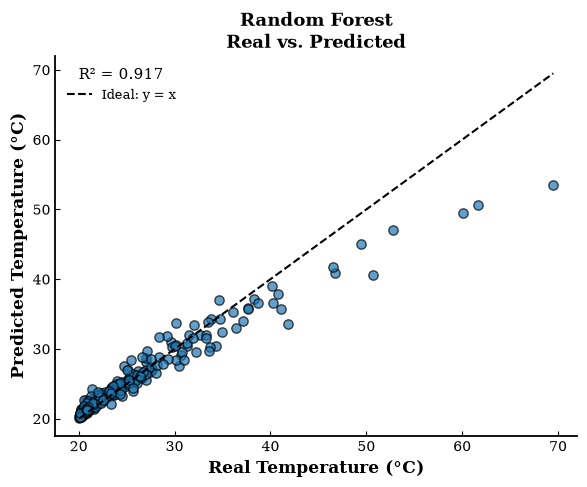

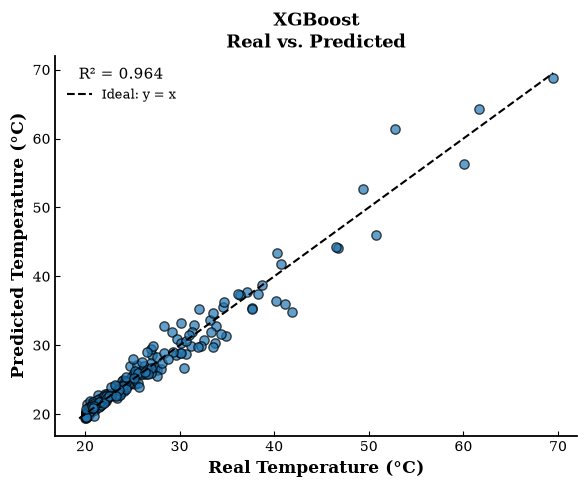

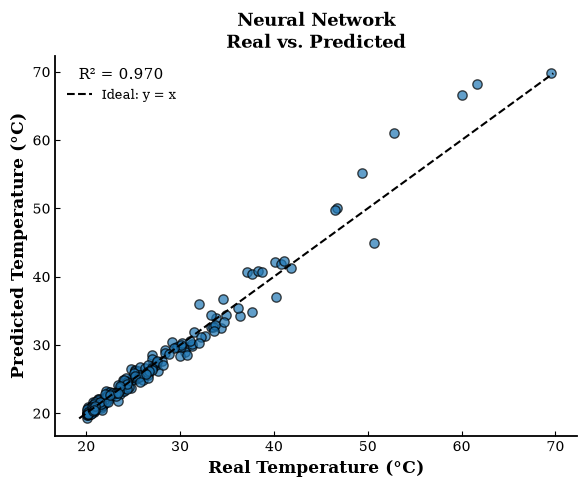

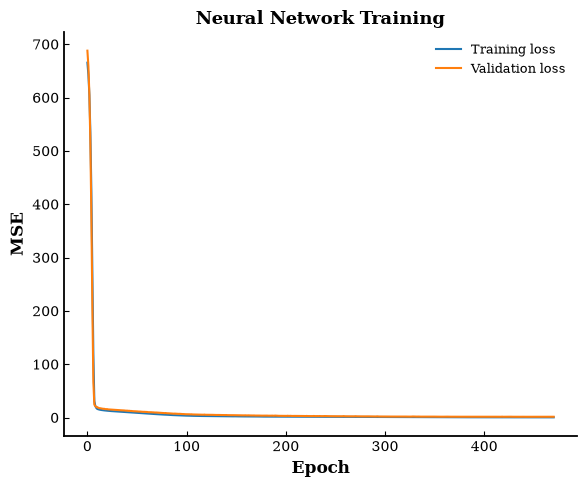

In [23]:
# ============================================================

def plot_test_prediction(y_true, y_pred, model_name):
    metrics = regression_metrics(y_true, y_pred)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.70, s=45, edgecolor="black")
    ax.plot([lower, upper], [lower, upper], "k--", linewidth=1.5, label="Ideal: y = x")
    ax.set_title(f"{model_name}\nReal vs. Predicted")
    ax.set_xlabel("Real Temperature (°C)")
    ax.set_ylabel("Predicted Temperature (°C)")
    ax.legend(title=f"R² = {metrics['R²']:.3f}")
    adjust_axes(ax)
    plt.tight_layout()
    plt.show()


for name, pred in pred_test.items():
    plot_test_prediction(y_test, pred, name)


# Historia de entrenamiento de la red neuronal.
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(history.history["loss"], label="Training loss")
ax.plot(history.history["val_loss"], label="Validation loss")
ax.set_title("Neural Network Training")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend()
adjust_axes(ax)
plt.tight_layout()
plt.show()


In [24]:
# ============================================================
# 10. FUNCIÓN ÚNICA DE PREDICCIÓN


In [25]:
# ============================================================

def predecir_temperatura(Corriente, n_in, x_length, y_length, grosor, avisar_rango=True):
    """Predice la temperatura con los tres modelos para una geometría dada."""

    nuevo = pd.DataFrame([{
        "Corriente": Corriente,
        "n_in": n_in,
        "x_length": x_length,
        "y_length": y_length,
        "grosor": grosor,
    }], columns=FEATURES)

    # Aviso de extrapolación. No bloquea la predicción.
    if avisar_rango:
        fuera = []
        for col in FEATURES:
            value = nuevo.at[0, col]
            min_value = X[col].min()
            max_value = X[col].max()
            if value < min_value or value > max_value:
                fuera.append(f"{col}={value:g} (rango: {min_value:g}–{max_value:g})")

        if fuera:
            print("\nADVERTENCIA: parámetros fuera del rango de entrenamiento:")
            for item in fuera:
                print(" -", item)

    pred_rf = float(model_rf.predict(nuevo)[0])
    pred_xgb = float(model_xgb.predict(nuevo)[0])

    nuevo_scaled = scaler.transform(nuevo)
    pred_nn = float(model_nn.predict(nuevo_scaled, verbose=0).ravel()[0])

    return pred_rf, pred_xgb, pred_nn


In [26]:
# ============================================================
# 11. PREDICCIONES PARA LA VALIDACIÓN EXPERIMENTAL


In [27]:
# ============================================================

# IMPORTANTE: estos parámetros deben corresponder exactamente
# a la geometría utilizada en los calentadores experimentales.
VALIDATION_GEOMETRY = {
    "n_in": 10,
    "x_length": 2,
    "y_length": 2,
    "grosor": 0.00015,
}

modelos_vals = np.array([
    predecir_temperatura(
        Corriente=current,
        **VALIDATION_GEOMETRY,
    )
    for current in CURRENTS
])

# filas = corriente; columnas = modelo
print("\n===== PREDICCIONES PARA VALIDACIÓN =====")
df_predictions = pd.DataFrame(modelos_vals, columns=MODEL_NAMES)
df_predictions.insert(0, "Corriente (A)", CURRENTS)
print(df_predictions.round(4).to_string(index=False))



ADVERTENCIA: parámetros fuera del rango de entrenamiento:
 - Corriente=0.1 (rango: 0.1004–0.99996)
 - x_length=2 (rango: 3.5051–9.9981)
 - y_length=2 (rango: 2.5–3.4993)

ADVERTENCIA: parámetros fuera del rango de entrenamiento:
 - x_length=2 (rango: 3.5051–9.9981)
 - y_length=2 (rango: 2.5–3.4993)

ADVERTENCIA: parámetros fuera del rango de entrenamiento:
 - x_length=2 (rango: 3.5051–9.9981)
 - y_length=2 (rango: 2.5–3.4993)

ADVERTENCIA: parámetros fuera del rango de entrenamiento:
 - x_length=2 (rango: 3.5051–9.9981)
 - y_length=2 (rango: 2.5–3.4993)

ADVERTENCIA: parámetros fuera del rango de entrenamiento:
 - x_length=2 (rango: 3.5051–9.9981)
 - y_length=2 (rango: 2.5–3.4993)

===== PREDICCIONES PARA VALIDACIÓN =====
 Corriente (A)  Random Forest  XGBoost  Neural Network
           0.1        27.6834  27.1969         33.0483
           0.2        27.8976  28.2717         37.7193
           0.3        28.5656  29.1755         42.7201
           0.4        30.9082  30.8631         

In [28]:
# ============================================================
# 12. DATOS EXPERIMENTALES


In [29]:
# ============================================================

# Cada fila contiene los 10 calentadores medidos a una corriente.
res = np.array([
    [25.37887725, 24.48018287, 24.09208617, 24.46390581, 26.42723647,
     21.34539729, 23.90534870, 27.42824349, 27.50727405, 21.63962224],

    [34.36210170, 33.19015431, 32.48925701, 33.41168938, 32.30196693,
     34.65976102, 35.09807615, 35.50635271, 35.13272846, 32.85688778],

    [44.28414980, 44.24404709, 42.64571794, 44.90105160, 41.63316834,
     46.17051754, 45.87383517, 47.33273697, 45.47879760, 44.59204409],

    [58.92605261, 59.27863176, 55.79004559, 59.92068387, 57.93684569,
     62.98379810, 56.40588627, 63.19700701, 60.39955511, 56.55186673],

    [82.74228357, 76.88696944, 73.98845441, 84.56582064, 78.95441182,
     80.90838226, 78.08088176, 89.20828257, 84.60739830, 81.08492535],
], dtype=float)

# Desviaciones estándar reportadas para cada calentador. Se conservan
# como información experimental, aunque las gráficas siguientes usan
# la dispersión entre los 10 valores de temperatura de cada corriente.
std_exp = np.array([
    [2.22327986, 1.85405299, 2.01567475, 1.91663033, 1.86770210,
     1.01944678, 2.16070685, 1.30913981, 1.16674816, 1.28584854],

    [0.86626325, 0.50350967, 0.66381148, 0.83689135, 0.94867121,
     1.14467369, 1.02757261, 1.04850678, 1.00194207, 0.82254640],

    [1.30971940, 1.12300017, 0.94910552, 1.50421330, 1.87231570,
     1.75609659, 1.51279989, 1.95289183, 1.37004981, 1.62866956],

    [2.23705823, 2.03109875, 1.43949931, 2.82425698, 3.34063400,
     3.22862760, 2.08960637, 3.31714663, 2.58813017, 2.38200429],

    [5.00540432, 3.10627911, 3.12034966, 6.05287157, 5.20391194,
     5.72152495, 4.29601100, 7.41066685, 5.46413415, 5.65463861],
], dtype=float)

if res.shape[0] != len(CURRENTS):
    raise ValueError("res debe contener una fila por cada corriente.")


In [30]:
# ============================================================
# 13. COMPARACIÓN INDIVIDUAL CON LOS 10 CALENTADORES


In [31]:
# ============================================================

comparaciones = []

for current_idx, current in enumerate(CURRENTS):
    for heater_idx, experimental in enumerate(res[current_idx], start=1):
        for model_idx, model_name in enumerate(MODEL_NAMES):
            prediction = modelos_vals[current_idx, model_idx]
            error = prediction - experimental

            comparaciones.append({
                "Corriente (A)": current,
                "Calentador": heater_idx,
                "Modelo": model_name,
                "Experimental (°C)": experimental,
                "Predicción (°C)": prediction,
                "Error (°C)": error,
                "Error absoluto (°C)": abs(error),
                "Error (%)": abs(error) / experimental * 100,
            })


df_comparaciones = pd.DataFrame(comparaciones)

# Métricas globales usando los 50 valores experimentales.
validation_metrics = []

for model_idx, model_name in enumerate(MODEL_NAMES):
    y_exp = res.ravel()
    y_model = np.repeat(modelos_vals[:, model_idx], res.shape[1])

    row = {"Modelo": model_name}
    row.update(regression_metrics(y_exp, y_model))
    validation_metrics.append(row)


df_validation_metrics = pd.DataFrame(validation_metrics)

print("\n===== MÉTRICAS DE VALIDACIÓN EXPERIMENTAL =====")
print(df_validation_metrics.round(4).to_string(index=False))



===== MÉTRICAS DE VALIDACIÓN EXPERIMENTAL =====
        Modelo  RMSE (°C)  MAE (°C)  MAPE (%)      R²  Bias (°C)  Error máximo (°C)
 Random Forest    26.0799   20.2017   34.5779 -0.6981   -18.9951            55.7134
       XGBoost    25.9041   19.8923   33.7239 -0.6753   -18.8586            55.4832
Neural Network    14.1947   10.6429   20.7620  0.4970    -5.7165            35.7170


In [32]:
# ============================================================
# 14. ESTADÍSTICAS EXPERIMENTALES Y BOOTSTRAP


In [33]:
# ============================================================

exp_mean = res.mean(axis=1)
exp_std = res.std(axis=1, ddof=1)
exp_min = res.min(axis=1)
exp_max = res.max(axis=1)

# Matriz: corriente x 10 000 medias bootstrap.
bootstrap_means = np.empty((len(CURRENTS), N_BOOTSTRAP))
bootstrap_mean_ci = np.empty((len(CURRENTS), 2))

for i, values in enumerate(res):
    result = bootstrap(
        (values,),
        np.mean,
        n_resamples=N_BOOTSTRAP,
        confidence_level=0.95,
        method="percentile",
        random_state=RANDOM_STATE,
    )

    bootstrap_means[i] = np.asarray(result.bootstrap_distribution).ravel()
    bootstrap_mean_ci[i] = [
        result.confidence_interval.low,
        result.confidence_interval.high,
    ]

# Vectorización: corriente x modelo x 10 000 errores.
# Convención usada en todo el análisis:
# error = predicción - experimental.
bootstrap_errors = modelos_vals[:, :, None] - bootstrap_means[:, None, :]

bootstrap_summary = []

for i, current in enumerate(CURRENTS):
    for j, model_name in enumerate(MODEL_NAMES):
        errors = bootstrap_errors[i, j]

        bootstrap_summary.append({
            "Corriente (A)": current,
            "Modelo": model_name,
            "Predicción (°C)": modelos_vals[i, j],
            "Media experimental (°C)": exp_mean[i],
            "IC95 media inferior (°C)": bootstrap_mean_ci[i, 0],
            "IC95 media superior (°C)": bootstrap_mean_ci[i, 1],
            "Error medio bootstrap (°C)": errors.mean(),
            "MAE bootstrap (°C)": np.abs(errors).mean(),
            "IC95 error inferior (°C)": np.percentile(errors, 2.5),
            "IC95 error superior (°C)": np.percentile(errors, 97.5),
        })


df_bootstrap = pd.DataFrame(bootstrap_summary)

print("\n===== RESULTADOS BOOTSTRAP =====")
print(df_bootstrap.round(4).to_string(index=False))



===== RESULTADOS BOOTSTRAP =====
 Corriente (A)         Modelo  Predicción (°C)  Media experimental (°C)  IC95 media inferior (°C)  IC95 media superior (°C)  Error medio bootstrap (°C)  MAE bootstrap (°C)  IC95 error inferior (°C)  IC95 error superior (°C)
           0.1  Random Forest          27.6834                  24.6668                   23.4116                   25.9061                      3.0248              3.0248                    1.7773                    4.2718
           0.1        XGBoost          27.1969                  24.6668                   23.4116                   25.9061                      2.5384              2.5384                    1.2908                    3.7853
           0.1 Neural Network          33.0483                  24.6668                   23.4116                   25.9061                      8.3898              8.3898                    7.1422                    9.6368
           0.2  Random Forest          27.8976                  33.900

In [34]:
# ============================================================
# 15. COMPARACIÓN GENERAL: EXPERIMENTAL VS. LOS TRES MODELOS


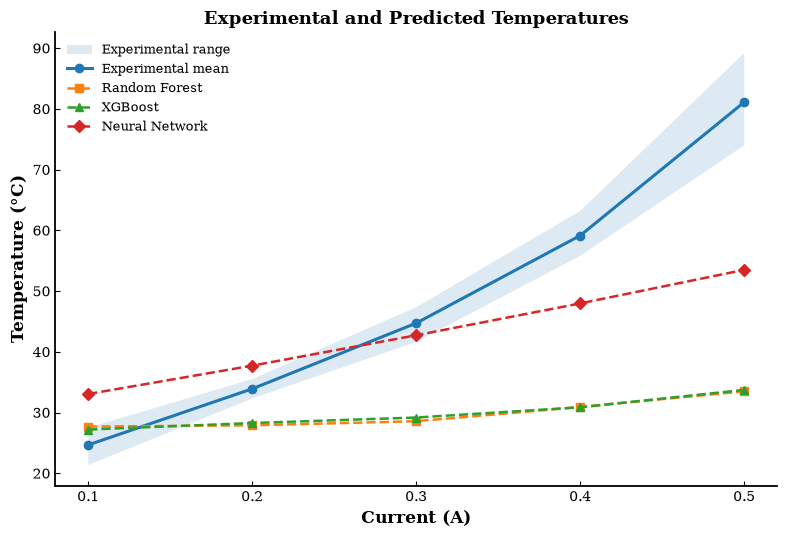

In [35]:
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.fill_between(
    CURRENTS,
    exp_min,
    exp_max,
    alpha=0.15,
    label="Experimental range",
)

ax.plot(
    CURRENTS,
    exp_mean,
    "o-",
    linewidth=2.2,
    label="Experimental mean",
)

markers = ["s", "^", "D"]
for j, model_name in enumerate(MODEL_NAMES):
    ax.plot(
        CURRENTS,
        modelos_vals[:, j],
        marker=markers[j],
        linestyle="--",
        linewidth=1.8,
        label=model_name,
    )

ax.set_title("Experimental and Predicted Temperatures")
ax.set_xlabel("Current (A)")
ax.set_ylabel("Temperature (°C)")
ax.set_xticks(CURRENTS)
ax.legend()
adjust_axes(ax)
plt.tight_layout()
plt.show()


In [36]:
# ============================================================
# 16. FUNCIONES PARA LA MACROFIGURA DE VALIDACIÓN


In [37]:
# ============================================================

def plot_evolution(ax, pred, model_name):
    ax.fill_between(CURRENTS, exp_min, exp_max, alpha=0.15, label="Experimental range")
    ax.errorbar(
        CURRENTS,
        exp_mean,
        yerr=exp_std,
        fmt="o-",
        capsize=4,
        linewidth=1.8,
        label="Experimental mean ± SD",
    )
    ax.plot(CURRENTS, pred, "^-", linewidth=1.8, label=model_name)
    ax.set_title("(a) Temperature vs. Current")
    ax.set_xlabel("Current (A)")
    ax.set_ylabel("Temperature (°C)")
    ax.set_xticks(CURRENTS)
    ax.legend(fontsize=8)
    adjust_axes(ax)


def plot_predicted_vs_experimental(ax, pred):
    lower = min(exp_mean.min(), pred.min())
    upper = max(exp_mean.max(), pred.max())

    ax.scatter(exp_mean, pred, s=60)
    ax.plot([lower, upper], [lower, upper], "k--", linewidth=1.2, label="Ideal: y = x")
    ax.set_title("(b) Predicted vs. Experimental")
    ax.set_xlabel("Experimental Temperature (°C)")
    ax.set_ylabel("Predicted Temperature (°C)")
    ax.legend()
    adjust_axes(ax)


def plot_absolute_error(ax, pred):
    abs_error = np.abs(pred - exp_mean)
    ax.bar(CURRENTS, abs_error, width=0.045, alpha=0.75)
    ax.set_title("(c) Absolute Error")
    ax.set_xlabel("Current (A)")
    ax.set_ylabel("Absolute Error (°C)")
    ax.set_xticks(CURRENTS)
    adjust_axes(ax)


def plot_bland_altman(ax, pred):
    averages = (pred + exp_mean) / 2
    differences = pred - exp_mean
    bias = differences.mean()
    sd_diff = differences.std(ddof=1)
    upper_loa = bias + 1.96 * sd_diff
    lower_loa = bias - 1.96 * sd_diff

    ax.scatter(averages, differences, s=60)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(bias, linestyle="--", label=f"Bias = {bias:.2f} °C")
    ax.axhline(upper_loa, color="gray", linestyle=":", label=f"Upper LoA = {upper_loa:.2f}")
    ax.axhline(lower_loa, color="gray", linestyle=":", label=f"Lower LoA = {lower_loa:.2f}")
    ax.set_title("(d) Bland–Altman Plot")
    ax.set_xlabel("Mean Temperature (°C)")
    ax.set_ylabel("Prediction − Experimental (°C)")
    ax.legend(fontsize=8)
    adjust_axes(ax)


def plot_relative_error(ax, pred):
    relative_error = np.abs(pred - exp_mean) / exp_mean * 100
    ax.plot(CURRENTS, relative_error, "s-", linewidth=1.8)
    ax.set_title("(e) Relative Error")
    ax.set_xlabel("Current (A)")
    ax.set_ylabel("Relative Error (%)")
    ax.set_xticks(CURRENTS)
    adjust_axes(ax)


def plot_bootstrap_errors(ax, model_idx):
    errors = [bootstrap_errors[i, model_idx] for i in range(len(CURRENTS))]

    ax.boxplot(
        errors,
        tick_labels=[f"{c:.1f}" for c in CURRENTS],
        showmeans=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.4},
        meanprops={
            "marker": "o",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 4,
        },
    )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("(f) Bootstrap Error Distribution")
    ax.set_xlabel("Current (A)")
    ax.set_ylabel("Prediction − Experimental (°C)")
    adjust_axes(ax)


In [38]:
# ============================================================
# 17. MACROFIGURA PARA CADA MODELO


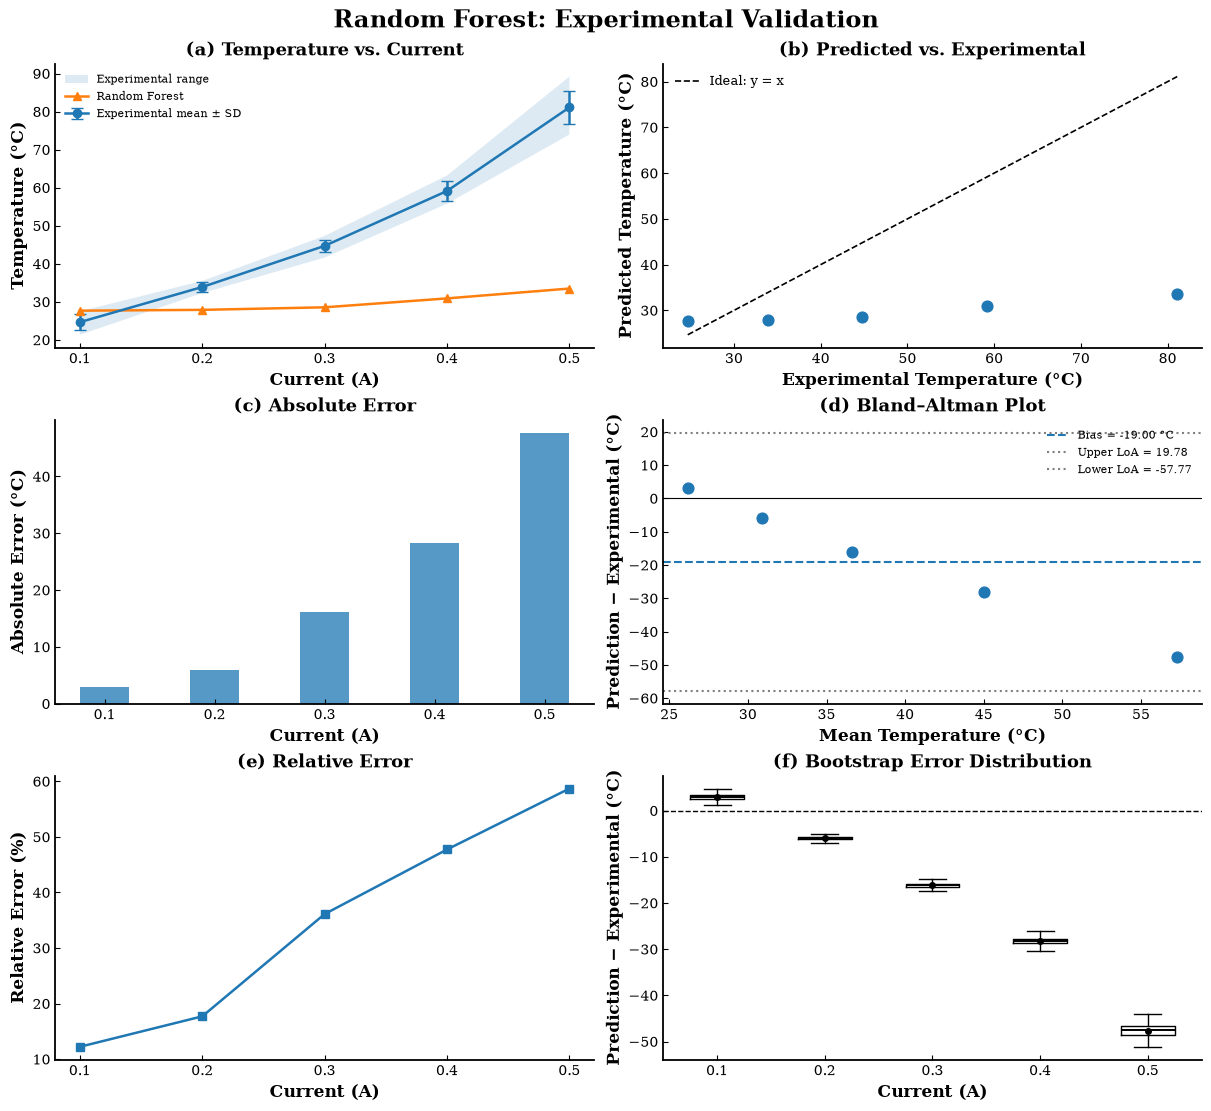

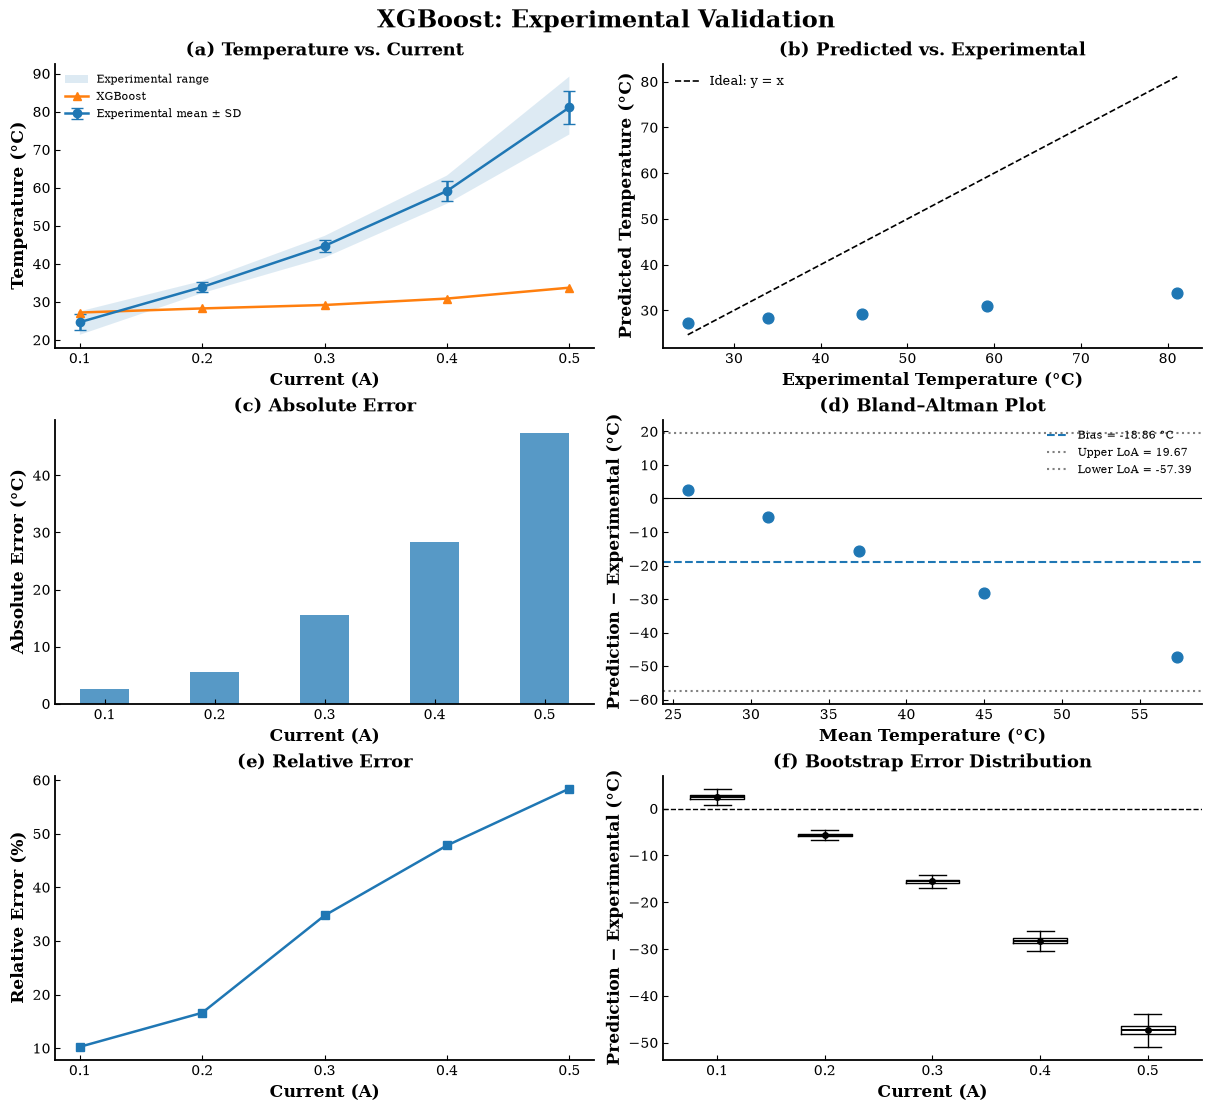

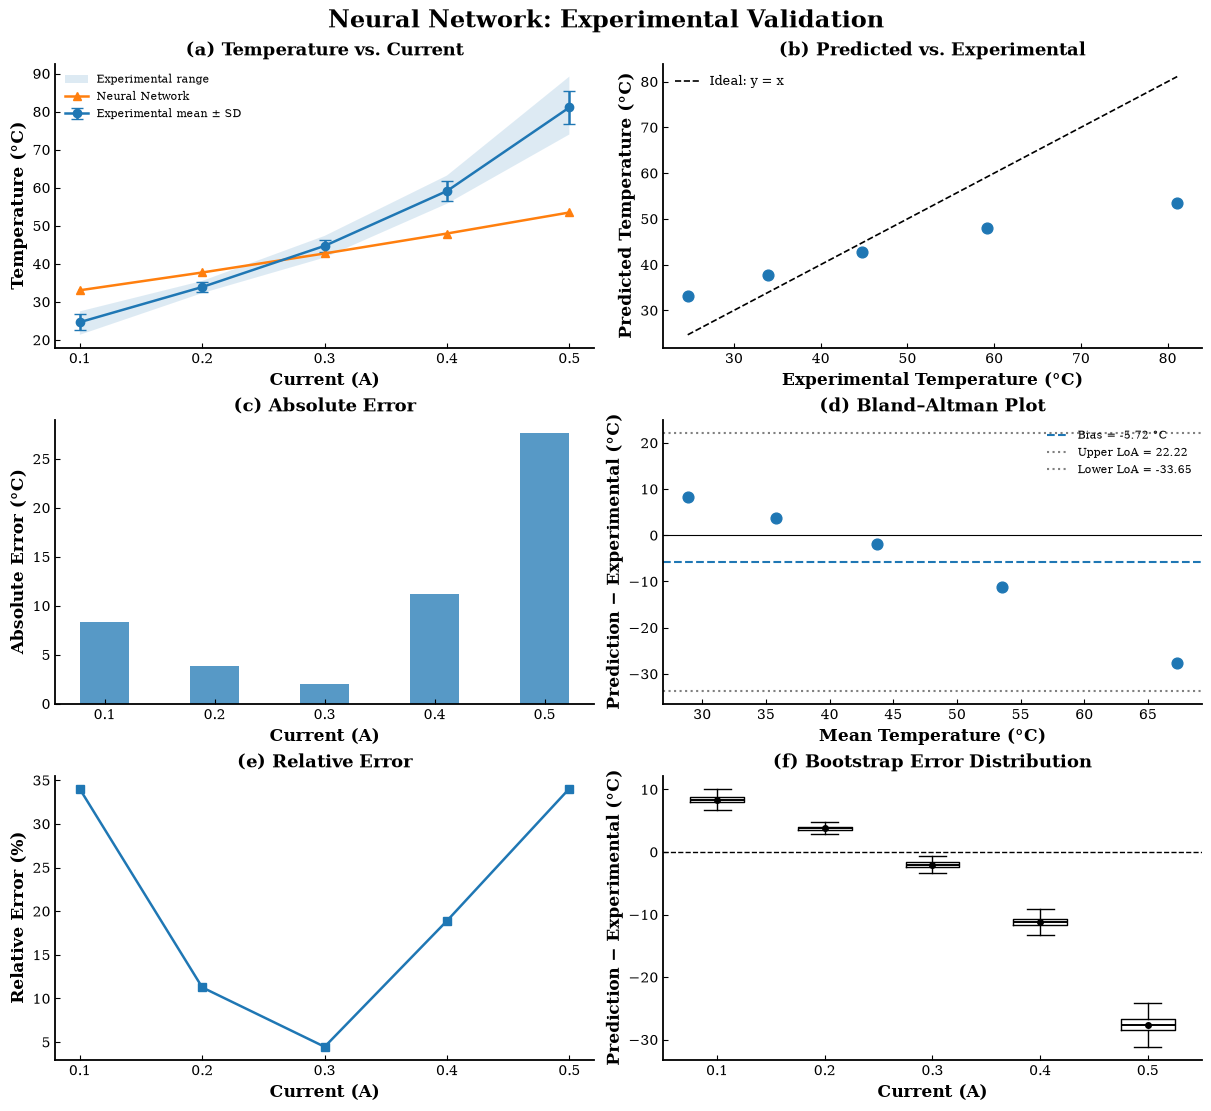

In [39]:
# ============================================================

for model_idx, model_name in enumerate(MODEL_NAMES):
    pred = modelos_vals[:, model_idx]

    fig, axes = plt.subplots(3, 2, figsize=(12, 11), constrained_layout=True)
    fig.suptitle(f"{model_name}: Experimental Validation", fontsize=17, fontweight="bold")

    plot_evolution(axes[0, 0], pred, model_name)
    plot_predicted_vs_experimental(axes[0, 1], pred)
    plot_absolute_error(axes[1, 0], pred)
    plot_bland_altman(axes[1, 1], pred)
    plot_relative_error(axes[2, 0], pred)
    plot_bootstrap_errors(axes[2, 1], model_idx)

    filename = f"validation_{model_name.lower().replace(' ', '_')}.png"
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


In [40]:
# ============================================================
# 18. BOXPLOT GLOBAL DEL BOOTSTRAP


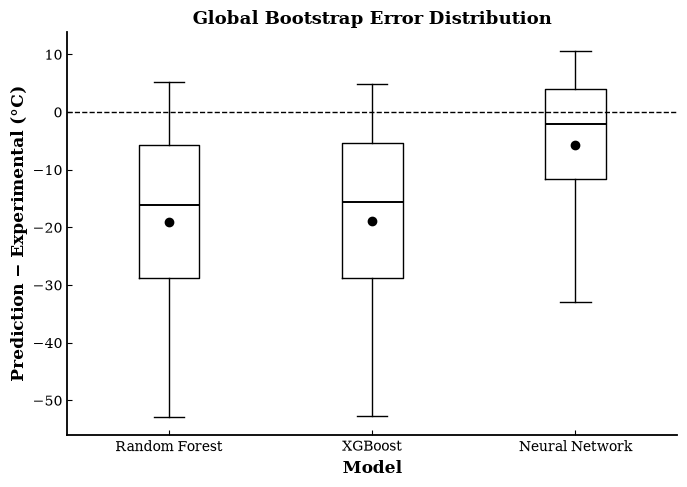

In [41]:
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

global_errors = [
    bootstrap_errors[:, model_idx, :].ravel()
    for model_idx in range(len(MODEL_NAMES))
]

ax.boxplot(
    global_errors,
    tick_labels=MODEL_NAMES,
    showmeans=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.4},
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
    },
)

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Global Bootstrap Error Distribution")
ax.set_xlabel("Model")
ax.set_ylabel("Prediction − Experimental (°C)")
adjust_axes(ax)
plt.tight_layout()
plt.show()


In [42]:
# ============================================================
# 19. EXPORTAR RESULTADOS


In [44]:
# ============================================================

with pd.ExcelWriter("resultados_validacion.xlsx") as writer:
    df_test_metrics.to_excel(writer, sheet_name="Metricas_test", index=False)
    df_predictions.to_excel(writer, sheet_name="Predicciones", index=False)
    df_comparaciones.to_excel(writer, sheet_name="Comparaciones", index=False)
    df_validation_metrics.to_excel(writer, sheet_name="Metricas_validacion", index=False)
    df_bootstrap.to_excel(writer, sheet_name="Bootstrap", index=False)

print("\nArchivo guardado: resultados_validacion.xlsx")



Archivo guardado: resultados_validacion.xlsx


In [45]:
model_nn.save("modelo_red_neuronal.keras")